In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [11]:
data = pd.read_csv("city_temperature.csv")
del data["State"]
data = data[(data["AvgTemperature"] != -99) & (data["City"] == "Seattle")]
print(data.info())
print(data.head())

C:\Users\ACER\AppData\Local\Temp\ipykernel_10396\1329825772.py:1: DtypeWarning: Columns (0: State) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("city_temperature.csv")


<class 'pandas.DataFrame'>
Index: 9249 entries, 2806890 to 2816154
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          9249 non-null   str    
 1   Country         9249 non-null   str    
 2   City            9249 non-null   str    
 3   Month           9249 non-null   int64  
 4   Day             9249 non-null   int64  
 5   Year            9249 non-null   int64  
 6   AvgTemperature  9249 non-null   float64
dtypes: float64(1), int64(3), str(3)
memory usage: 578.1 KB
None
                Region Country     City  Month  Day  Year  AvgTemperature
2806890  North America      US  Seattle      1    1  1995            41.3
2806891  North America      US  Seattle      1    2  1995            39.8
2806892  North America      US  Seattle      1    3  1995            44.5
2806893  North America      US  Seattle      1    4  1995            42.4
2806894  North America      US  Seattle      1    5  1995    

In [12]:
df = data.pivot_table(values='AvgTemperature', index='Year', columns='Month', aggfunc='mean')
df

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
1995,46.125806,45.578571,47.383871,50.816667,59.874194,62.040000,66.483871,62.303226,63.226667,51.900000,48.803333,41.948387
1996,39.706452,42.555172,46.735484,50.993333,52.196774,59.723333,67.612903,65.967742,58.183333,51.167742,43.056667,39.145161
1997,41.112903,42.217857,44.451613,48.900000,57.961290,58.796667,63.974194,66.967742,61.690000,51.045161,48.820000,41.745161
1998,42.200000,45.560714,46.358065,49.746667,54.216129,58.856667,66.377419,65.700000,62.333333,52.080645,46.700000,39.603704
1999,41.980000,42.225000,43.503226,48.180000,51.312903,57.153333,61.593548,63.700000,60.166667,51.664516,47.326667,41.835484
2000,40.061290,43.406897,44.174194,50.490000,53.074194,60.010000,63.258065,62.503226,59.440000,52.429032,42.486667,40.564516
2001,42.216129,40.396429,45.025806,47.313333,54.380645,57.016667,61.696774,63.719355,59.246667,50.667742,46.726667,41.632258
2002,41.212903,41.771429,41.487097,48.053333,52.361290,60.557692,64.380645,64.390323,60.324138,51.158065,46.813333,43.116129
2003,45.570968,41.750000,46.426667,48.190000,53.983871,62.743333,67.067742,65.464516,61.900000,54.267742,42.540000,41.929032


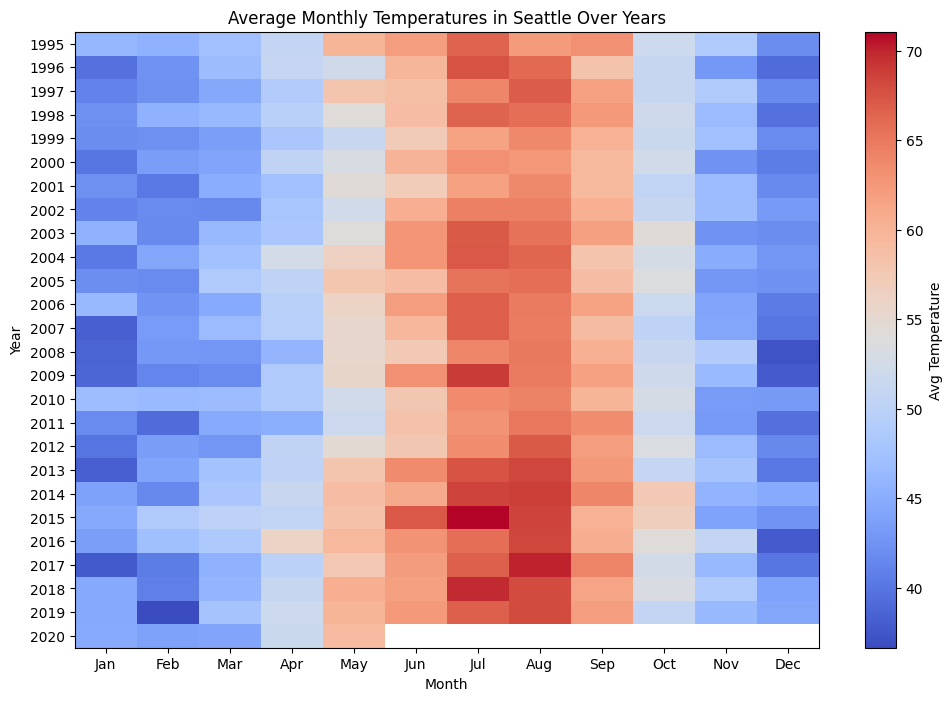

In [13]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 8))
plt.imshow(df, cmap='coolwarm', aspect='auto')
plt.xticks(range(12), months)
plt.yticks(range(len(df.index)), df.index)
plt.colorbar(label='Avg Temperature')
plt.xlabel('Month')
plt.ylabel('Year')
plt.title('Average Monthly Temperatures in Seattle Over Years')
plt.grid(False)
plt.savefig("seattle_temperatures_heatmap.png")
plt.show()

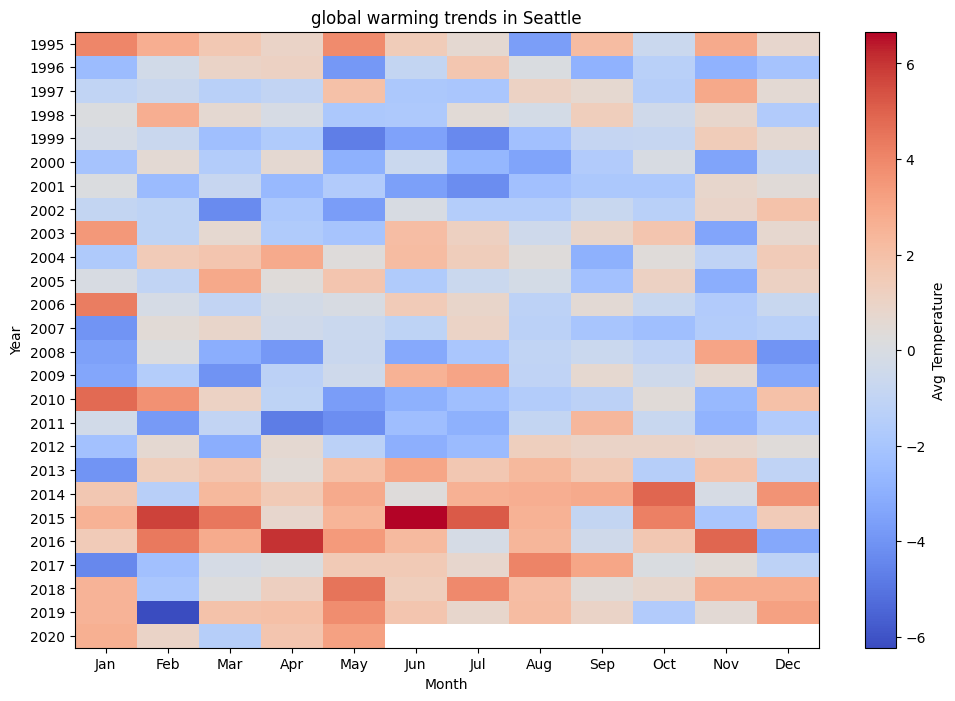

In [14]:
df = df - df.mean()
plt.figure(figsize=(12, 8))
plt.imshow(df, cmap='coolwarm', aspect='auto')
plt.xticks(range(12), months)
plt.yticks(range(len(df.index)), df.index)
plt.colorbar(label='Avg Temperature')
plt.xlabel('Month')
plt.ylabel('Year')
plt.title('global warming trends in Seattle')
plt.grid(False)
plt.savefig("seattle_temperatures_heatmap_unusual.png")
plt.show()